In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import sympy
import random
from ase.io import read

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
from sympy import symbols, simplify, sin, expand
import sympy as sp
import pymc as pm
import arviz as az

In [3]:
atoms_train = read("/home/paolo/Na_dataset/train_Na_new.xyz", index=":")
atoms_test = read("/home/paolo/Na_dataset/test_Na_new.xyz", index=":")

In [4]:
data_train = pd.concat(
    [pd.DataFrame([a.info for a in atoms_train]),
     pd.DataFrame({'volume': [a.get_volume() for a in atoms_train]})],
    axis=1
)
data_test = pd.concat(
    [pd.DataFrame([a.info for a in atoms_test]),
     pd.DataFrame({'volume': [a.get_volume() for a in atoms_test]})],
    axis=1
)

In [5]:
data_train

,Ea,B,N,O,F,Na,Al,Si,P,S,...,face-area-max,face-area-avg,face-area-min,face-area-count,pockets-per-ion,pockets-per-volume,paths-per-ion,paths-per-volume,poly_dist_avg_fixed,volume
0,0.365113,0.000000,0.0,0.631387,0.000000,0.127737,0.000000,0.000000,0.171533,0.000000,...,10.973040,2.521378,2.554994e-06,24.784055,5.371429,0.046887,45.342857,0.395793,0.385197,16038.697093
1,0.425024,0.000000,0.0,0.467925,0.000000,0.184906,0.000000,0.000000,0.135849,0.000000,...,11.777366,2.837638,8.278834e-07,29.008265,1.173469,0.011507,5.484694,0.053782,0.375974,19988.125341
2,0.274638,0.113043,0.0,0.000000,0.000000,0.208696,0.108696,0.000000,0.000000,0.304348,...,15.033404,3.383426,2.368494e-11,39.474009,2.583333,0.021100,14.566667,0.118978,0.080752,29383.692649
3,0.324737,0.000000,0.0,0.000000,0.000000,0.101124,0.000000,0.243446,0.033708,0.621723,...,12.877547,3.444336,5.345359e-06,40.587672,8.425926,0.032273,51.564815,0.197504,0.116010,28196.892709
4,0.345059,0.000000,0.0,0.407692,0.000000,0.219231,0.000000,0.000000,0.161538,0.000000,...,15.090982,3.165906,4.092372e-09,35.067899,2.105263,0.021466,13.359649,0.136222,0.363843,22360.631045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,0.321759,0.000000,0.0,0.000000,0.000000,0.241935,0.000000,0.000000,0.161290,0.451613,...,12.864103,3.268545,4.741584e-07,37.803003,1.360784,0.012972,5.980392,0.057011,0.091131,26749.291087
1037,0.389788,0.000000,0.0,0.380711,0.106599,0.335025,0.177665,0.000000,0.000000,0.000000,...,8.761876,1.934795,1.569696e-06,12.466122,0.335859,0.008334,2.255051,0.055958,0.317510,15958.495344
1038,0.393305,0.250000,0.0,0.500000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,...,8.829005,1.864119,7.645468e-07,13.897762,0.412000,0.008600,1.924000,0.040160,0.368284,11977.043019
1039,0.335168,0.000000,0.0,0.417969,0.000000,0.187500,0.000000,0.000000,0.027344,0.000000,...,13.544451,2.987695,7.102955e-06,32.194261,3.026042,0.029022,16.453125,0.157799,0.301010,20019.155151


In [6]:
def initialize(df, med_flag = False):
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    T = 300
    ln_D_all = np.array(df['logD'])
    if (med_flag == True):
        med =  np.median(ln_D_all).round()
        ln_D = ln_D_all[ln_D_all>med]
        ind = np.where(ln_D_all > med)[0]
    else:
        med = -100
        ln_D = ln_D_all[ln_D_all>med]
        ind = np.where(ln_D_all > med)[0]
    
    return {
        "ln_D_all" : ln_D_all,
        "ln_D" : ln_D,
        "T" : np.repeat(T, len(ln_D_all)),
        "E_T" : np.array(df['Ea'], dtype = 'float')[ind]/(kb*T),
        "E" : np.array(df['Ea'], dtype = 'float')[ind],
        "V" : np.array(df['volume'], dtype = 'float')[ind],
        
        # Atomic fractions of a given element
        "B":  np.array(df['B'], dtype='float')[ind],
        "N":  np.array(df['N'], dtype='float')[ind],
        "O":  np.array(df['O'], dtype='float')[ind],
        "F":  np.array(df['F'], dtype='float')[ind],
        "Na": np.array(df['Na'], dtype='float')[ind],
        "Al": np.array(df['Al'], dtype='float')[ind],
        "Si": np.array(df['Si'], dtype='float')[ind],
        "P":  np.array(df['P'], dtype='float')[ind],
        "S":  np.array(df['S'], dtype='float')[ind],
        "Cl": np.array(df['Cl'], dtype='float')[ind],
        "Ge": np.array(df['Ge'], dtype='float')[ind],
        "Br": np.array(df['Br'], dtype='float')[ind],
        "I":  np.array(df['I'], dtype='float')[ind],

        # Density in g/A^3
        "density": np.array(df['density'], dtype='float')[ind]*10**(-24),
        # Average Atomic Volume
        "AAV": np.array(df['AAV'], dtype='float')[ind],
        # Packing fraction
        "PF": np.array(df['PF'], dtype='float')[ind],
        # set-of-non-Na-atoms bond ionicity
        "SBI": np.array(df['SBI'], dtype='float')[ind],
        # Volume per anion
        "VPA": np.array(df['VPA'], dtype='float')[ind],
        # Na bond ionicity
        "NBI": np.array(df['NBI'], dtype='float')[ind],
        # Ratio of NBI and SBI
        "RBI": np.array(df['RBI'], dtype='float')[ind],
        # Weighted electronegativity
        "WE": np.array(df['weighted_electronegativity'], dtype='float')[ind],
        # -Na-Na (are just the Na-Na distances)
        "Na-Na": np.array(df['Na-Na'], dtype='float')[ind],
        "Na-Na-max": np.array(df['Na-Na-max'], dtype='float')[ind],
        "Na-Na-avg": np.array(df['Na-Na-avg'], dtype='float')[ind],
        # -bottleneck (free distance available for a Na⁺ ion to pass through the narrowest part of a diffusion pathway formed by surrounding framework atoms (typically O²⁻, S²⁻, or halides))
        "bottleneck_min": np.array(df['bottleneck_min'], dtype='float')[ind],
        "bottleneck_avg": np.array(df['bottleneck_avg'], dtype='float')[ind],
        # -poly_dist (Polyhedral distortion is the degree to which the bond lengths and bond angles of a coordination polyhedron differ from those of an ideal reference polyhedron.)
        "poly_dist_max": np.array(df['poly_dist_max'], dtype='float')[ind],
        "poly_dist_std": np.array(df['poly_dist_std'], dtype='float')[ind],
        "poly_dist_avg": np.array(df['poly_dist_avg'], dtype='float')[ind],
        "poly_dist_avg_fixed": np.array(df['poly_dist_avg_fixed'], dtype='float')[ind],
        # -face-area   (area of the shared face between two neighboring Voronoi polyhedra corresponding to adjacent Na sites it represents the cross-sectional area available for Na⁺ migration between those sites)
        "face-area-max": np.array(df['face-area-max'], dtype='float')[ind],
        "face-area-avg": np.array(df['face-area-avg'], dtype='float')[ind],
        "face-area-min": np.array(df['face-area-min'], dtype='float')[ind],
        "face-area-count": np.array(df['face-area-count'], dtype='float')[ind],
        # -pockets  (free-volume region in the crystal structure where a Na⁺ ion can reside with relatively low energy, typically corresponding to a stable or metastable Na site)
        "pockets-per-ion": np.array(df['pockets-per-ion'], dtype='float')[ind],
        "pockets-per-volume": np.array(df['pockets-per-volume'], dtype='float')[ind],
        # -paths  (connected sequence of pockets linked by Voronoi faces and constrained by bottlenecks, forming a continuous route that allows Na⁺ ions to move through the crystal lattice)
        "paths-per-ion": np.array(df['paths-per-ion'], dtype='float')[ind],
        "paths-per-volume": np.array(df['paths-per-volume'], dtype='float')[ind],
    }

In [9]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize(data_train)
lnDvsE = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data['ln_D']))], 
    "E_T": data['E_T'],
    #"rho": (data['density'] - data['density'].mean()) / data['density'].std(),
    "AAV (A^3)": data['AAV'],
    "PF": data['PF'],
    "VPA (A^3)": data['VPA'],
    "NBI": data['NBI'],
    "SBI": data['SBI'],
    "RBI": data['RBI'],
    "WE": data['WE'],
    "B": data['B'],
    "N": data['N'],
    "S": data['S'],
    "O": data['O'],
    "F": data['F'],
    "Na": data['Na'],
    "Al": data['Al'],
    "Si": data['Si'],
    "P": data['P'],
    "Cl": data['Cl'],
    "Ge": data['Ge'],
    "Br": data['Br'],
    "I": data['I'],

    # Volume
    "cub_root_V (A)" : data['V']**(1/3),
    
    # Na–Na distances
    "Na-Na (A)": data['Na-Na'],
    "Na-Na-max (A)": data['Na-Na-max'],
    "Na-Na-avg (A)": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min (A)": data['bottleneck_min'],
    "bottleneck_avg (A)": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data['poly_dist_max'],
    "poly_dist_std": data['poly_dist_std'],
    "poly_dist_avg": data['poly_dist_avg'],
    "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max (A^2)": data['face-area-max'],
    "face-area-avg (A^2)": data['face-area-avg'],
    "face-area-min (A^2)": data['face-area-min'],
    "face-area-count": data['face-area-count'],

    # Pockets
    "pockets-per-ion": data['pockets-per-ion'],
    "pockets-per-volume (A^-3)": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data['paths-per-ion'],
    "paths-per-volume (A^-3)": data['paths-per-volume'],

    # Target
    "ln_D": data['ln_D']
})

In [34]:
# n_feat = 39
# lnDvsE.to_csv(f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_withunits.csv", index=False)
# data_file = f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_withunits.csv"
# os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [11]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 3
n_feat = 39
Diff_json = {
    'data_file': "/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff39_temp300_withunits3.csv",
     'property_key': 'ln_D',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/desc_dim/lndiff{n_feat}_{rung}_{desc_dim}_withunits.json", "w"), indent=4)

In [7]:
def extract_dd3(ms = 10, rung=1, feat = 39):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=3'''
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/desc_dim/models_lndiff{feat}_{rung}_{dd}_withunits/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [8]:
raw_formulas, a0_list, a1_list, a2_list, c0_list = extract_dd3()

In [9]:
raw_formulas

['c0 + a0 * (face-area-avg * NBI) + a1 * (Al + O) + a2 * (O + E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (Al + O) + a2 * (O + E_T)',
 'c0 + a0 * (Al - B) + a1 * (face-area-avg * E_T) + a2 * (O + E_T)',
 'c0 + a0 * (Al + O) + a1 * (face-area-avg / E_T) + a2 * (O + E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (O / RBI) + a2 * (O + E_T)',
 'c0 + a0 * (F + B) + a1 * (E_T / cub_root_V) + a2 * (AAV / E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (poly_dist_avg / RBI) + a2 * (O + E_T)',
 'c0 + a0 * (PF / NBI) + a1 * (O / RBI) + a2 * (O + E_T)',
 'c0 + a0 * (PF / NBI) + a1 * (Al + O) + a2 * (O + E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (poly_dist_avg_fixed / RBI) + a2 * (O + E_T)']

In [10]:
def sanitize(expr):
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [11]:
formulas = [sanitize(f) for f in raw_formulas]
formulas

['c0 + a0 * (face_area_avg * NBI) + a1 * (Al + O) + a2 * (O + E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (Al + O) + a2 * (O + E_T)',
 'c0 + a0 * (Al - B) + a1 * (face_area_avg * E_T) + a2 * (O + E_T)',
 'c0 + a0 * (Al + O) + a1 * (face_area_avg / E_T) + a2 * (O + E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (O / RBI) + a2 * (O + E_T)',
 'c0 + a0 * (F + B) + a1 * (E_T / cub_root_V) + a2 * (AAV / E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (poly_dist_avg / RBI) + a2 * (O + E_T)',
 'c0 + a0 * (PF / NBI) + a1 * (O / RBI) + a2 * (O + E_T)',
 'c0 + a0 * (PF / NBI) + a1 * (Al + O) + a2 * (O + E_T)',
 'c0 + a0 * (cub_root_V * WE) + a1 * (poly_dist_avg_fixed / RBI) + a2 * (O + E_T)']

In [13]:
a0 = np.array(a0_list, dtype=float)
a1 = np.array(a1_list, dtype=float)
a2 = np.array(a2_list, dtype=float)
c0 = np.array(c0_list, dtype=float)

In [21]:
# define symbols
a0_sym, a1_sym, a2_sym, c0_sym = sp.symbols('a0 a1 a2 c0')
symbols = sp.symbols(
    '''
    E_T B N O F Na Al Si P S Cl Ge Br I
    density AAV PF SBI RBI VPA NBI WE cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
        sp.simplify(f.coeff(a1_sym)),
        sp.simplify(f.coeff(a2_sym)),
    ]
    pruned.append(row)

pruned

[[NBI*face_area_avg, Al + O, E_T + O],
 [WE*cub_root_V, Al + O, E_T + O],
 [Al - B, E_T*face_area_avg, E_T + O],
 [Al + O, face_area_avg/E_T, E_T + O],
 [WE*cub_root_V, O/RBI, E_T + O],
 [B + F, E_T/cub_root_V, AAV/E_T],
 [WE*cub_root_V, poly_dist_avg/RBI, E_T + O],
 [PF/NBI, O/RBI, E_T + O],
 [PF/NBI, Al + O, E_T + O],
 [WE*cub_root_V, poly_dist_avg_fixed/RBI, E_T + O]]

In [23]:
vars_ = [
    locals_dict[k] for k in [
        'E_T', 'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'WE', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [24]:
data = initialize(data_train)
X = np.array([
    phi(
        data['E_T'],
        data['B'],
        data['N'],
        data['S'],
        data['O'],
        data['F'],
        data['Na'],
        data['Al'],
        data['Si'],
        data['P'],
        data['Cl'],
        data['Ge'],
        data['Br'],
        data['I'],
        
        data['AAV'],
        data['PF'],
        data['NBI'],
        data['SBI'],
        data['RBI'],
        data['VPA'],
        data['WE'],
        
        
        # Volume
        data['V']**(1/3),
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data['poly_dist_max'],
        data['poly_dist_std'],
        data['poly_dist_avg'],
        data['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data['face-area-count'],
        
        # Pockets
        data['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [26]:
data = initialize(data_test)
X_test = np.array([
    phi(
        data['E_T'],
        data['B'],
        data['N'],
        data['S'],
        data['O'],
        data['F'],
        data['Na'],
        data['Al'],
        data['Si'],
        data['P'],
        data['Cl'],
        data['Ge'],
        data['Br'],
        data['I'],
        
        data['AAV'],
        data['PF'],
        data['NBI'],
        data['SBI'],
        data['RBI'],
        data['VPA'],
        data['WE'],
        
        
        # Volume
        data['V']**(1/3),
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data['poly_dist_max'],
        data['poly_dist_std'],
        data['poly_dist_avg'],
        data['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data['face-area-count'],
        
        # Pockets
        data['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [27]:
X.shape, X_test.shape

((10, 3, 1041), (10, 3, 261))

In [32]:
traces1 = []
ppcs = []
data = initialize(data_train)
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors
        c0_coeff = pm.Normal("c0", mu=c0[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0[i], sigma=10)
        a1_coeff = pm.Normal("a1", mu=a1[i], sigma=10)
        a2_coeff = pm.Normal("a2", mu=a2[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data['ln_D'])

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :] + a1_coeff * f_test[1, :] + a2_coeff * f_test[2, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)

        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        #trace = pm.sample()
        traces1.append(trace)
        ppcs.append(ppc)
        idata = trace.posterior
        az.to_netcdf(idata, f"trace_model_{i}.nc")
        az.to_netcdf(ppc, f"pp_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [34]:
c0[0], a0[0], a1[0], a2[0]

(np.float64(-11.87256912695403),
 np.float64(1.469851661171671),
 np.float64(-2.745211996193482),
 np.float64(-0.7516376199737155))

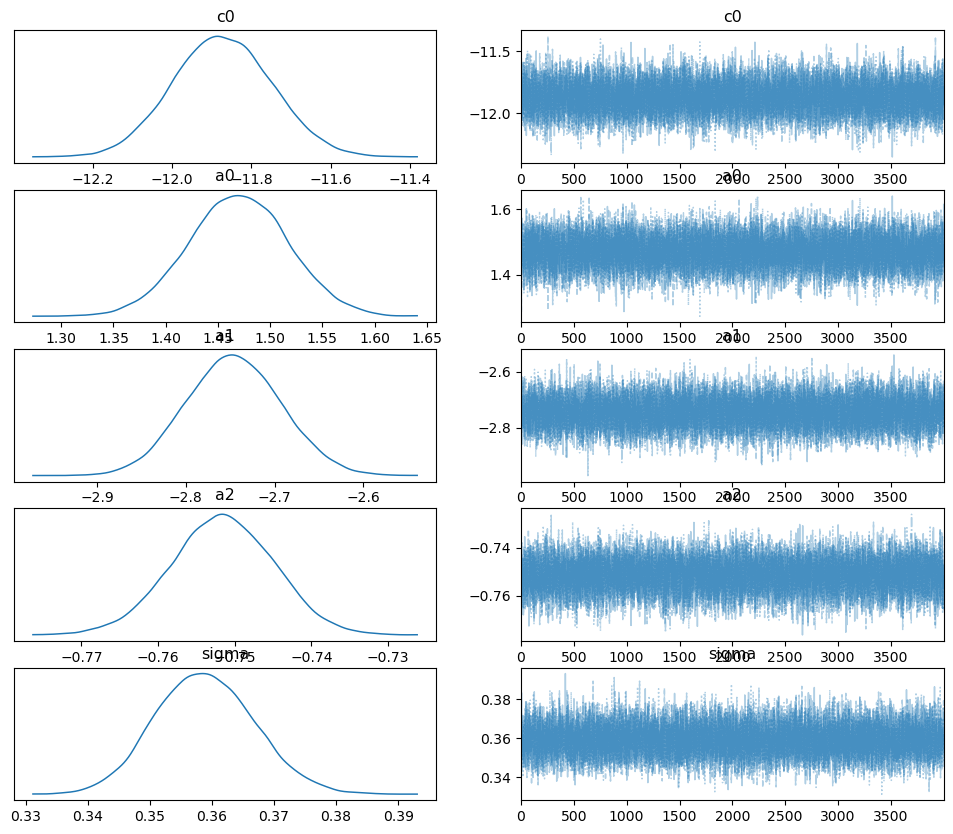

In [35]:
az.plot_trace(traces1[0], combined=True);

In [49]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces1[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-439.91802348 -439.85921343 -439.46076165 -438.05822533]
[-447.91245771 -447.649574   -446.02877471 -448.75908258]
[-474.2790186  -474.64921211 -472.93674292 -472.37764704]
[-469.46465018 -469.15784406 -468.54153743 -469.20351856]
[-497.15839678 -497.24540966 -497.48369725 -494.89898915]
[-495.88639078 -494.71917174 -495.75688682 -494.5298765 ]
[-508.26520106 -506.7403083  -507.27352768 -507.39014408]
[-510.94987    -508.96043548 -508.25562614 -507.28210168]
[-514.19565609 -514.47832475 -512.81860701 -510.61645382]
[-517.55261627 -516.6965356  -517.18130583 -517.56264369]


In [50]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml 

(np.float64(-439.3240559738547), np.int64(0))

In [51]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(0.0002577768484793174),
 np.float64(1.3528009228397788e-15),
 np.float64(1.180307059565009e-13),
 np.float64(1.2117433259667963e-25),
 np.float64(5.288855325985145e-25),
 np.float64(2.675974146479664e-30),
 np.float64(6.310314590095995e-31),
 np.float64(9.797268519735658e-33),
 np.float64(1.4386048480092152e-34)]

In [52]:
np.argsort(ml_diff)

array([9, 8, 7, 6, 4, 5, 2, 3, 1, 0])

## Calibration

In [ ]:
files = [f"/home/paolo/Thesis/Na/mc_desc_dim_withunits_lnD_dd3/trace_model_{i}.nc" for i in range(10)]
traces_list = [az.from_netcdf(f) for f in files]
traces1 = traces_list

In [37]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
a1_samples_list = []
a2_samples_list = []
sigma_samples_list = []
models_stored = 10
for m in range(models_stored):
# Draws 200 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces1[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces1[m].posterior['a0'].values.flatten(), size=200, replace=True))
    a1_samples_list.append(np.random.choice(traces1[m].posterior['a1'].values.flatten(), size=200, replace=True))
    a2_samples_list.append(np.random.choice(traces1[m].posterior['a2'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces1[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
a1_samples = np.array(a1_samples_list).T
a2_samples = np.array(a2_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

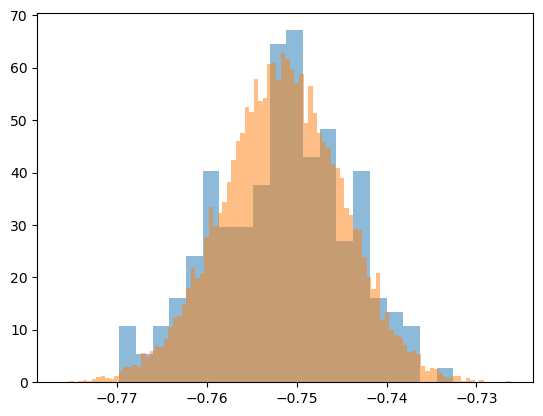

In [38]:
plt.hist(np.array(a2_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces1[0].posterior['a2'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [160]:
X.shape

(10, 5, 1041)

In [166]:
c0_samples.shape

(200, 10)

In [39]:
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m])
# Empirical mean over the models
y_emp

array([[-22.25565803, -22.21016337, -21.87017409, ..., -22.18023943,
        -22.15266408, -22.07719995],
       [-23.1571424 , -23.2126549 , -22.71663864, ..., -22.93237054,
        -23.30642716, -22.92198848],
       [-17.76262109, -17.80085049, -17.84798743, ..., -17.67694757,
        -17.81910656, -17.75006368],
       ...,
       [-23.36718613, -23.22256001, -23.06995353, ..., -23.52270753,
        -23.08562954, -23.79504795],
       [-20.2621583 , -20.55957655, -20.2028237 , ..., -20.33604787,
        -20.59978844, -20.27923605],
       [-24.20380741, -24.26804685, -24.55212252, ..., -24.32481786,
        -24.41644408, -24.33395842]], shape=(1041, 10))

In [40]:
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.16683074, 0.18328648, 0.16710729, ..., 0.17138794, 0.16919335,
        0.21047178],
       [0.17166534, 0.18578192, 0.17474024, ..., 0.17483908, 0.17299033,
        0.21273145],
       [0.15944005, 0.17627389, 0.16232882, ..., 0.16500956, 0.16227216,
        0.20291438],
       ...,
       [0.16504734, 0.17897546, 0.16736257, ..., 0.17539467, 0.17170005,
        0.20666109],
       [0.1659522 , 0.18092376, 0.16651304, ..., 0.16862036, 0.16636876,
        0.20770821],
       [0.17030458, 0.18221329, 0.17226808, ..., 0.17937065, 0.17608509,
        0.2087695 ]], shape=(1041, 10))

In [41]:
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [42]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.78823684, 0.72944514, 0.82373821, 0.5578952 , 0.75550322,
       0.61654315, 0.73778951, 0.86511583, 0.88792629, 0.72069468])

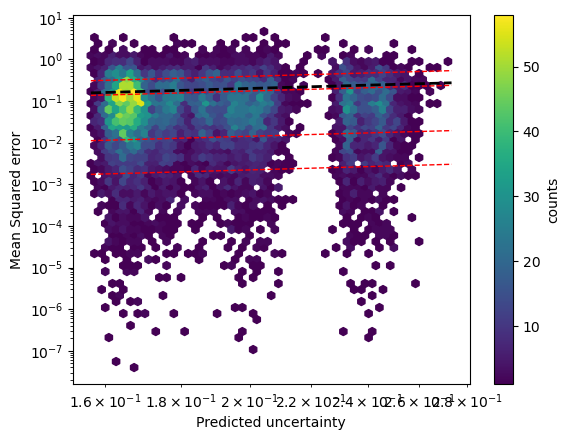

In [43]:
x = var_emp
y = (y_obs - y_emp)**2
# reference line
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label='y = x')

# quantiles in log space
log_ratios = np.log10(y / x)
quantiles = [0.1, 0.25, 0.75, 0.9]

for q in quantiles:
    q_val = 10 ** np.quantile(log_ratios, q)
    plt.plot(xline, q_val * xline,
             linestyle='--',
             color='red',
             lw=1)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')

plt.colorbar(label='counts')
plt.xlabel("Predicted uncertainty")
plt.ylabel("Mean Squared error")
plt.xscale('log')
plt.yscale('log')
# plt.ylim(xmin,xmax)
#plt.xlim(xmin,xmax)
#plt.savefig('quant.png')
plt.show()

In [ ]:
files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_withunits_lnD_dd3/pp_model_{i}.nc" for i in range(10)]
ppcs = [az.from_netcdf(f) for f in files_ppc]

In [44]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

In [45]:
y_test = np.array(data_test['logD'])

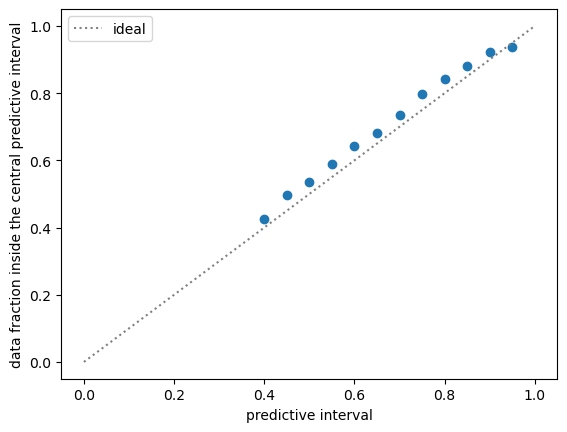

In [48]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[2].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

# E vs Rest

In [22]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize(data_train)
EvsRest = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data['ln_D']))], 
    "rho (g/cm^3)": data['density'],
    "AAV (A^3)": data['AAV'],
    "PF": data['PF'],
    "VPA (A^3)": data['VPA'],
    "NBI": data['NBI'],
    "SBI": data['SBI'],
    "RBI": data['RBI'],
    "WE": data['WE'],
    "B": data['B'],
    "N": data['N'],
    "S": data['S'],
    "O": data['O'],
    "F": data['F'],
    "Na": data['Na'],
    "Al": data['Al'],
    "Si": data['Si'],
    "P": data['P'],
    "Cl": data['Cl'],
    "Ge": data['Ge'],
    "Br": data['Br'],
    "I": data['I'],

    # Volume
    "cub_root_V (A)" : data['V']**(1/3),
    
    # Na–Na distances
    "Na-Na (A)": data['Na-Na'],
    "Na-Na-max (A)": data['Na-Na-max'],
    "Na-Na-avg (A)": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min (A)": data['bottleneck_min'],
    "bottleneck_avg (A)": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data['poly_dist_max'],
    "poly_dist_std": data['poly_dist_std'],
    "poly_dist_avg": data['poly_dist_avg'],
    "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max (A^2)": data['face-area-max'],
    "face-area-avg (A^2)": data['face-area-avg'],
    "face-area-min (A^2)": data['face-area-min'],
    "face-area-count": data['face-area-count'],

    # Pockets
    "pockets-per-ion": data['pockets-per-ion'],
    "pockets-per-volume (A^-3)": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data['paths-per-ion'],
    "paths-per-volume (A^-3)": data['paths-per-volume'],

    # Target
    "E (eV)": data['E']
})

In [23]:
n_feat = 39
EvsRest.to_csv(f"/home/paolo/Thesis/Na/data/desc_dim/Na_Ea{n_feat}_temp300_withunits.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/desc_dim/Na_Ea{n_feat}_temp300_withunits.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [24]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 3
Diff_json = {
    'data_file': data_file,
     'property_key': 'E',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/desc_dim/Ea{n_feat}_{rung}_{desc_dim}_withunits.json", "w"), indent=4)

In [ ]:
# time input_parsing: 0.0443787 s
# Time to generate feat space: 0.0171525 s
# Projection time: 0.0012634 s
# Time to get best features on rank : 8.61e-05 s
# |---Complete final combination/selection from all ranks: 0.0003734 s
# Time for SIS: 0.0022545 s
# Time for l0-norm: 0.0041486 s
# Projection time: 0.0061839 s
# Time to get best features on rank : 7.82e-05 s
# |---Complete final combination/selection from all ranks: 0.0002974 s
# Time for SIS: 0.0081113 s
# Time for l0-norm: 0.0056609 s
# Projection time: 0.0045899 s
# Time to get best features on rank : 7.79e-05 s
# |---Complete final combination/selection from all ranks: 0.0003023 s
# Time for SIS: 0.0067895 s
# Time for l0-norm: 0.0247492 s
# Train RMSE: 0.034267 eV
# c0 + a0 * (face-area-count * face-area-max)

# Train RMSE: 0.0321761 eV
# c0 + a0 * (poly_dist_avg - SBI) + a1 * (face-area-count * face-area-max)

# Train RMSE: 0.0304895 eV
# c0 + a0 * (Ge * S) + a1 * (SBI - NBI) + a2 * (face-area-count * face-area-avg)
# Coefficients
# Task   a0                      a1                      a2                      c0
# all ,  4.261917926605502e-01, -1.321334713269502e-01, -7.944825917858859e-04,  3.615409540165300e-01, 

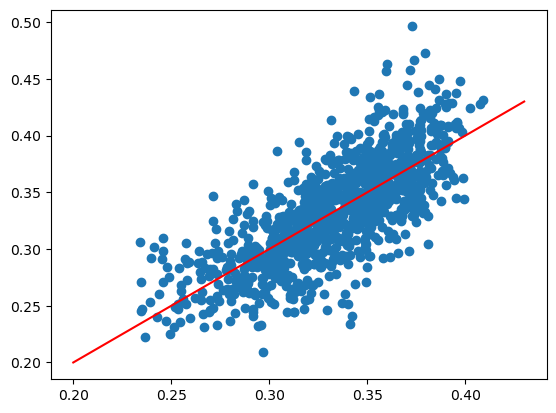

In [27]:
data = initialize(data_train)
a0 =  4.261917926605502e-01
a1 =  -1.321334713269502e-01
a2 =  -7.944825917858859e-04
c0 = 3.615409540165300e-01
fct = c0 + a0 * (data['Ge'] * data['S']) + a1 * (data['SBI'] - data['NBI']) + a2 * (data['face-area-count'] * data['face-area-avg'])
plt.scatter(fct, data['E'])
plt.plot([0.20,0.43], [0.20, 0.43], color = 'red')
plt.show()

In [25]:
def extract_dd3_Ea(ms = 10, rung=1, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=3'''
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/desc_dim/models_Ea{feat}_{rung}_{dd}_withunits/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [26]:
extract_dd3_Ea()

(['c0 + a0 * (Ge * S) + a1 * (SBI - NBI) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (poly_dist_avg - SBI) + a1 * (Ge * S) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (Ge * S) + a1 * (SBI - NBI) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (poly_dist_avg - SBI) + a1 * (Ge * S) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (Ge * S) + a1 * (Na-Na / RBI) + a2 * (face-area-count * cub_root_V)',
  'c0 + a0 * (Ge * S) + a1 * (Na-Na / RBI) + a2 * (face-area-count * face-area-avg)',
  'c0 + a0 * (poly_dist_avg - SBI) + a1 * (Ge * S) + a2 * (face-area-count * Na-Na)',
  'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face-area-count * face-area-max)'],
 ['4.261917926605502e-01',
  '4.312755927297620e-01',
  '1.279217290440420e-01',
  '4.39736091257